In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter 

In [2]:
df = pd.read_csv('flight_price_cleaned.csv')


In [3]:
df[['airline', 'ch_code', 'from', 'to', 'category']] = df[['airline', 'ch_code', 'from', 'to', 'category']].astype(object)

In [4]:
df.head()

,Unnamed: 0,airline,ch_code,from,to,price,category,day,month,dep_hr,dep_min,total_duration,total_stop
0,0,SpiceJet,SG,Delhi,Mumbai,5953,economy,11,2,18,55,130,0
1,1,SpiceJet,SG,Delhi,Mumbai,5953,economy,11,2,6,20,140,0
2,2,AirAsia,I5,Delhi,Mumbai,5956,economy,11,2,4,25,130,0
3,3,Vistara,UK,Delhi,Mumbai,5955,economy,11,2,10,20,135,0
4,4,Vistara,UK,Delhi,Mumbai,5955,economy,11,2,8,50,140,0


In [5]:
df.drop('Unnamed: 0', axis = 1, inplace= True)

In [6]:
#split in X and Y
X = df.drop('price', axis =1)
y = df['price']

In [7]:
X.info()

<class 'pandas.DataFrame'>
RangeIndex: 300261 entries, 0 to 300260
Data columns (total 11 columns):
 #   Column          Non-Null Count   Dtype 
---  ------          --------------   ----- 
 0   airline         300261 non-null  object
 1   ch_code         300261 non-null  object
 2   from            300261 non-null  object
 3   to              300261 non-null  object
 4   category        300261 non-null  object
 5   day             300261 non-null  int64 
 6   month           300261 non-null  int64 
 7   dep_hr          300261 non-null  int64 
 8   dep_min         300261 non-null  int64 
 9   total_duration  300261 non-null  int64 
 10  total_stop      300261 non-null  int64 
dtypes: int64(6), object(5)
memory usage: 25.2+ MB


In [8]:
#Let's drop CH code as well
X.drop('ch_code', axis =1, inplace= True)

In [9]:
#split in train and test
#train test split
from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)

x_train.shape, y_train.shape, x_test.shape, y_test.shape

((225195, 10), (225195,), (75066, 10), (75066,))

In [10]:
x_train.head()
#let's get numerical and categorical features out
num_features = X.select_dtypes(exclude= 'object').columns
cat_features = X.select_dtypes(include= 'object').columns

In [11]:
num_features, cat_features

(Index(['day', 'month', 'dep_hr', 'dep_min', 'total_duration', 'total_stop'], dtype='str'),
 Index(['airline', 'from', 'to', 'category'], dtype='str'))

In [12]:
#Std Stacling and one hot encoding
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer

numeric_transformer = StandardScaler()
cat_transfotmer = OneHotEncoder(drop= 'first')

Preprocessor = ColumnTransformer(
    [('StandardScaler', numeric_transformer, num_features),
    ('OneHotEncoder', cat_transfotmer, cat_features)],
    remainder= 'passthrough'
)

In [13]:
x_train = Preprocessor.fit_transform(x_train)
x_test = Preprocessor.transform(x_test)

In [14]:
#import metics
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

#create function to pass scores
def model_evaluator (true, predicted):
    mae = mean_absolute_error(true, predicted)
    mse = mean_squared_error(true, predicted)
    r2_square = r2_score(true, predicted)

    return mae, mse, r2_square


In [15]:
#import libs for each model
from sklearn.linear_model import LinearRegression, Lasso, Ridge
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor

#model list
models = {
    'Linear model' : LinearRegression(),
    'lasso' : Lasso(),
    'ridge': Ridge(),
    'tree': DecisionTreeRegressor(),
    'forest': RandomForestRegressor()
}

Linear model
for train model
mae: 4482.4061919462665
mse: 46349952.734815836
r2 score: 0.9100873420411527
for test model
mae: 4483.159804715121
mse: 46442097.42001908
r2 score: 0.9096298998651425


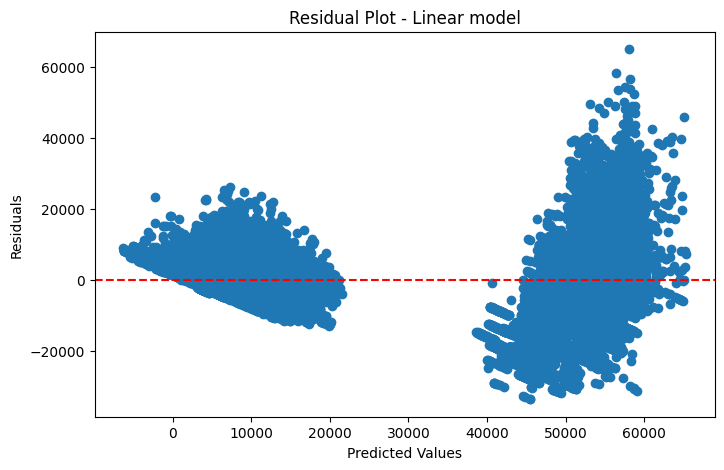

lasso
for train model
mae: 4480.1793353683015
mse: 46354906.50817061
r2 score: 0.9100777323888667
for test model
mae: 4480.509253481131
mse: 46444752.37518362
r2 score: 0.9096247336780536


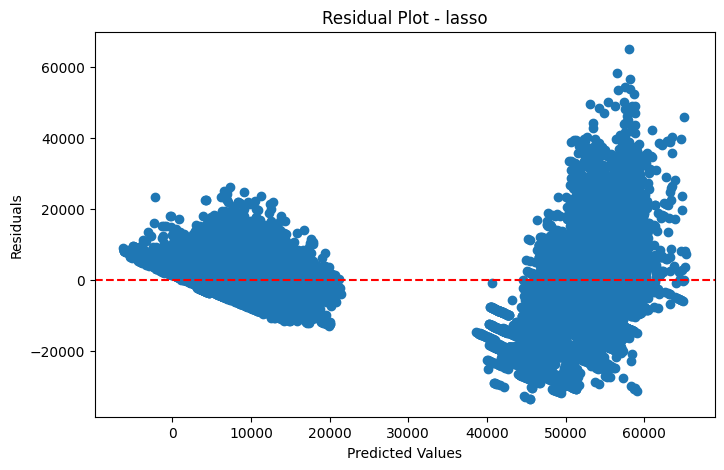

ridge
for train model
mae: 4482.379393553868
mse: 46349955.8090296
r2 score: 0.9100873360775925
for test model
mae: 4483.125662062288
mse: 46442089.73602813
r2 score: 0.9096299148171595


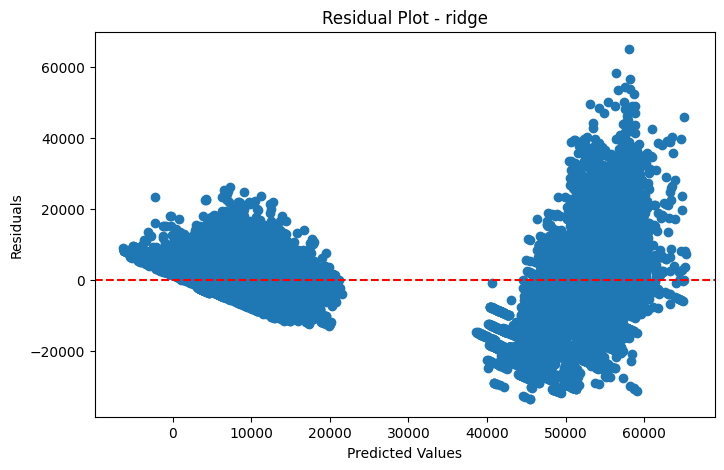

tree
for train model
mae: 17.267677642339603
mse: 89593.52248347727
r2 score: 0.999826200648176
for test model
mae: 976.9436207248733
mse: 9585386.195802879
r2 score: 0.9813481225339191


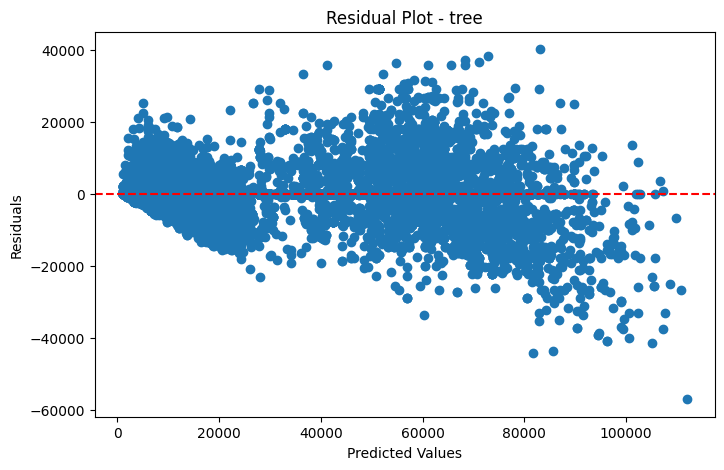

forest
for train model
mae: 355.31461415788857
mse: 874290.8720696737
r2 score: 0.9983039936073571
for test model
mae: 943.9042898912978
mse: 5924639.557489304
r2 score: 0.9884714450936393


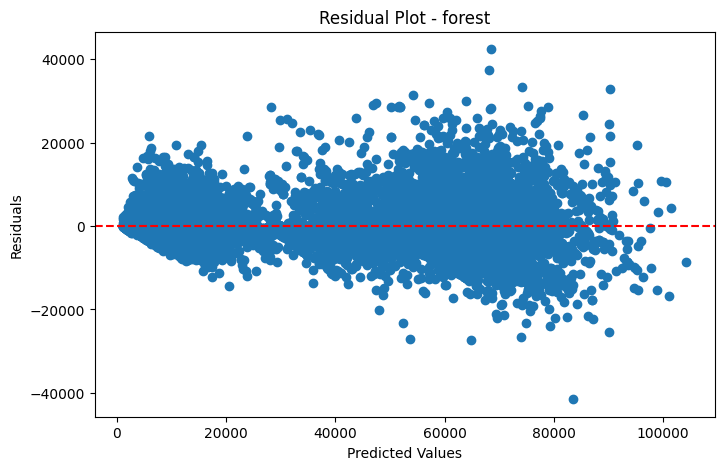

In [16]:
#predict and evaluate each model

for i in range(len(list(models))):
    model = list(models.values())[i]
    model.fit(x_train, y_train)
    y_train_pred = model.predict(x_train)
    y_test_pred = model.predict(x_test)

    #model traning metrics
    model_train_mae, model_train_mse, model_train_r2_score = model_evaluator(y_train,y_train_pred)

    #model test metrics
    model_test_mae, model_test_mse, model_test_r2_score = model_evaluator(y_test,y_test_pred)

    print('='*30)
    print(list(models.keys())[i])
    
    print('for train model')
    print('='*15)

    print('mae:', model_train_mae)
    print('mse:', model_train_mse)
    print('r2 score:', model_train_r2_score)

    print('for test model')
    print('='*15)

    print('mae:', model_test_mae)
    print('mse:', model_test_mse)
    print('r2 score:', model_test_r2_score)
    print('='*30)

    # residuals
    residuals = y_test - y_test_pred

    # residual plot
    plt.figure(figsize=(8,5))

    plt.scatter(y_test_pred, residuals)

    plt.axhline(y=0, color='r', linestyle='--')

    plt.xlabel("Predicted Values")
    plt.ylabel("Residuals")

    plt.title(f"Residual Plot - {list(models.keys())[i]}")

    plt.show()

    

Both decision tree and random forest offer good fit but both look overfitted

In [17]:
#hyperparameter tuning for both decision tree and random forest
#parameters for decision tree and random forest

tree_params = {'criterion': ['squared_error', 'friedman_mse'],
               'max_depth': [4,6,8,10],
                 'max_features': ['sqrt'],
                 'min_samples_split': [20,40],
                 'min_samples_leaf': [10, 20]}
forest_params = {'n_estimators': [150],
                'max_depth': [6, 8, 12],             # Keeps individual trees under control
                'min_samples_split': [8, 15],
                'min_samples_leaf': [4, 8],
                'max_features': [0.3, 0.5]
                 }

tree_model = DecisionTreeRegressor()
forest_model = RandomForestRegressor(n_jobs= -1)

In [18]:
#initiate random search CV
from sklearn.model_selection import RandomizedSearchCV
randomCV_models = [('tree', tree_model, tree_params),
                   ('forest', forest_model, forest_params)]
model_param = {}

for name, model, params in randomCV_models:
    random = RandomizedSearchCV(estimator= model,
                                param_distributions= params,
                                n_iter = 100,
                                cv = 3,
                                verbose= 1,
                                n_jobs= -1)
    random.fit(x_train, y_train)
    model_param[name] = random.best_params_

print(model_param)

c:\Users\Shubham\Desktop\Data Science Prep\DS Projects\venv\Lib\site-packages\sklearn\model_selection\_search.py:324: UserWarning: The total space of parameters 32 is smaller than n_iter=100. Running 32 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(


Fitting 3 folds for each of 32 candidates, totalling 96 fits


c:\Users\Shubham\Desktop\Data Science Prep\DS Projects\venv\Lib\site-packages\sklearn\model_selection\_search.py:324: UserWarning: The total space of parameters 24 is smaller than n_iter=100. Running 24 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(


Fitting 3 folds for each of 24 candidates, totalling 72 fits
{'tree': {'min_samples_split': 40, 'min_samples_leaf': 10, 'max_features': 'sqrt', 'max_depth': 10, 'criterion': 'friedman_mse'}, 'forest': {'n_estimators': 150, 'min_samples_split': 8, 'min_samples_leaf': 4, 'max_features': 0.5, 'max_depth': 12}}


In [21]:
#training models with refined results

Refined_models  = {
                    'tree': DecisionTreeRegressor(min_samples_split=  40, min_samples_leaf= 10, max_features= 'sqrt', max_depth= 10, criterion= 'friedman_mse'),
                    'forest': RandomForestRegressor(n_estimators= 150, min_samples_split= 8, min_samples_leaf= 4, max_features= .5, max_depth= 12, n_jobs= -1)
                }

tree
for train model
mae: 3370.761417930499
mse: 29007478.86260955
r2 score: 0.9437294026998393
for test model
mae: 3410.6296355028903
mse: 29702784.76750456
r2 score: 0.9422023598665797


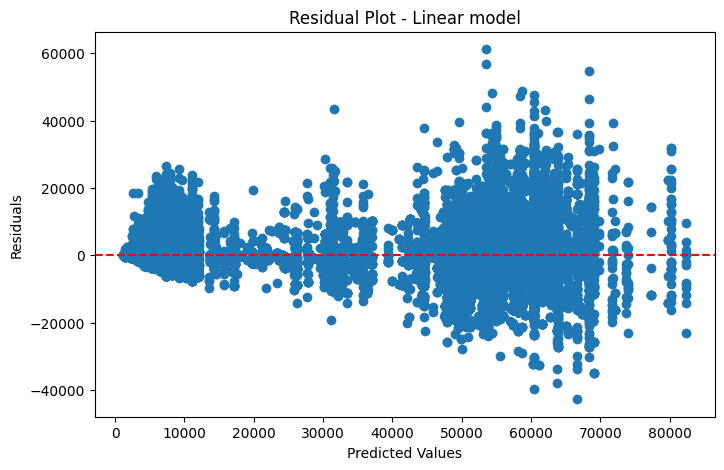

forest
for train model
mae: 2107.552134522452
mse: 14465558.631258057
r2 score: 0.9719387669532836
for test model
mae: 2156.0431869511
mse: 15189805.327367425
r2 score: 0.9704426736792582


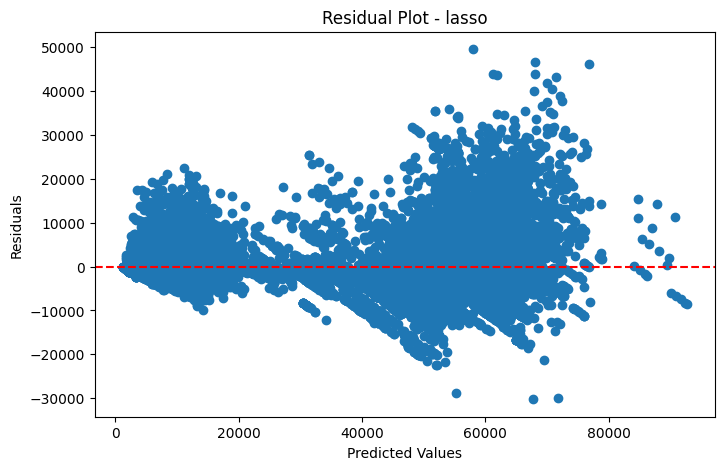

In [22]:
#predict and evaluate each refined model

for i in range(len(list(Refined_models))):
    model = list(Refined_models.values())[i]
    model.fit(x_train, y_train)
    y_train_pred_refined = model.predict(x_train)
    y_test_pred_refined = model.predict(x_test)

    #model traning metrics
    model_train_mae, model_train_mse, model_train_r2_score = model_evaluator(y_train,y_train_pred_refined)

    #model test metrics
    model_test_mae, model_test_mse, model_test_r2_score = model_evaluator(y_test,y_test_pred_refined)

    print('='*30)
    print(list(Refined_models.keys())[i])
    
    print('for train model')
    print('='*15)

    print('mae:', model_train_mae)
    print('mse:', model_train_mse)
    print('r2 score:', model_train_r2_score)

    print('for test model')
    print('='*15)

    print('mae:', model_test_mae)
    print('mse:', model_test_mse)
    print('r2 score:', model_test_r2_score)
    print('='*30)

    # residuals
    residuals = y_test - y_test_pred_refined

    # residual plot
    plt.figure(figsize=(8,5))

    plt.scatter(y_test_pred_refined, residuals)

    plt.axhline(y=0, color='r', linestyle='--')

    plt.xlabel("Predicted Values")
    plt.ylabel("Residuals")

    plt.title(f"Residual Plot - {list(models.keys())[i]}")

    plt.show()